# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.


    Nesse projeto o objetivo bem claro é identificar qual é o plano que gera mais receita para a empresa, tendo em vista os ajustes de orçamento que podem ser feitos a partir dessa definição. A ideia central é organizar os dados e realizar a limpeza dos dados brutos, com o objetivo de melhorar a identificação de possíveis problemas e melhorar a interpretação dos mesmos. E, assim, a partir disso trabalhar estatisticamente de forma a responder a pergunta gerada pelo objetivo geral do projeto.


## Inicialização

In [ ]:
import pandas as pd
import numpy as np
from math import factorial
from scipy import stats as st
import matplotlib.pyplot as plt
# Carregando todas as bibliotecas


## Carregue os dados

In [ ]:
calls = pd.read_csv('/datasets/megaline_calls.csv') # Carregue os arquivos de dados em diferentes DataFrames
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')


In [ ]:
## Prepare os dados

[Os dados deste projeto estão divididos em várias tabelas. Explore cada uma para obter uma compreensão inicial dos dados. Faça correções em cada tabela, se necessário.]

## Planos

In [ ]:
print(plans.info()) # Imprima informações gerais/resumo sobre o DataFrame dos planos


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None


In [ ]:
print(plans.head())
# Imprima uma amostra de dados dos planos


   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


Podemos observar que o DF tem apenas dois registros (os planos surf e ultimate) e não há valores ausentes.Acredito que não há problemas para a realização da leitura dos dados. Talvez realizar a transformação na coluna 'mb_per_month_included', substituir para 'gb_per_month_included', arredondando os valore e com isso ficando mais fácil a vizualização.



## Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [ ]:
plans['gb_per_month_included'] = plans['mb_per_month_included'] / 1024
plans = plans.drop('mb_per_month_included', axis=1) # Substituindo a coluna

plans = plans[['plan_name', 'gb_per_month_included', 'minutes_included',
               'messages_included', 'usd_monthly_pay', 'usd_per_gb',
               'usd_per_minute', 'usd_per_message']] # Reorganizando as colunas
print(plans.head())

  plan_name  gb_per_month_included  minutes_included  messages_included  \
0      surf                   15.0               500                 50   
1  ultimate                   30.0              3000               1000   

   usd_monthly_pay  usd_per_gb  usd_per_minute  usd_per_message  
0               20          10            0.03             0.03  
1               70           7            0.01             0.01  


## Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [ ]:
plans['plan_level'] = ''

plans.loc[plans['plan_name'] == 'surf', 'plan_level'] = 'Basic'
plans.loc[plans['plan_name'] == 'ultimate', 'plan_level'] = 'Premium'

print(plans['plan_level'])

0      Basic
1    Premium
Name: plan_level, dtype: object


## Usuários

In [ ]:
print(users.info()) # Imprima informações gerais/resumo sobre o DataFrame dos usuários


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None


In [ ]:
print(users.head()) # Imprima uma amostra de dados dos usuários


   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  


A partir da análise com .info() e .head(), pode-se perceber poucos problemas para serem corrigidos, que foram: a coluna 'reg_date' e 'churn_date' estão com dtype object quando o ideal seria estar em datatime; e existem valores ausentes na coluna 'churn_date', porém isso tem uma representatividade, que significa que o plano estava em uso quando o banco de dados foi extraído, talvez substituir 'NaN' para 'Em uso' poderia ser mais explicativo.


### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [ ]:
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [ ]:
# Criar uma coluna booleana 'is_churn'
# 'True' se 'churn_date' NÃO for nulo (usuário cancelou)
# 'False' se 'churn_date' for nulo (usuário está ativo/em uso)
users['is_churn'] = users['churn_date'].notna()
print(users['is_churn'].value_counts())


False    466
True      34
Name: is_churn, dtype: int64


## Chamadas

In [ ]:
print(calls.info()) # Imprima informações gerais/resumo sobre o DataFrame das chamadas


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None


In [ ]:
print(calls.head()) # Imprima uma amostra de dados das chamadas


         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


O DF calls também não apresenta problemas significativos, apenas deve-se realizar alguns ajustes para adequar a regra de arredondamento da empresa para cobrança na coluna  'duration' e a transformacao em datatime da coluna 'call_date'.


### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [ ]:
calls['call_date'] = pd.to_datetime(calls['call_date'])
calls['month'] = calls['call_date'].dt.month


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [ ]:
# Definição de uma função simples que recebe a data e retorna o mês
def extract_month(date_value):
    return date_value.month

# 2. Aplica a função à coluna 'call_date'
calls['month'] = calls['call_date'].apply(extract_month)

def round_up_simple(duration_value):
    # Converte o valor para o inteiro, truncando as decimais (ex: 1.3 vira 1, 2.8 vira 2)
    integer_part = int(duration_value)

    # Verifica se o valor original é maior que a parte inteira (ou seja, tem decimal)
    if duration_value > integer_part:
        # Se tiver decimal, arredonda para o próximo inteiro
        return integer_part + 1
    else:
        # Se não tiver decimal (já é inteiro), mantém o valor
        return integer_part
calls['duration_rounded'] = calls['duration'].apply(round_up_simple)

print(calls[['call_date', 'month']].head())

   call_date  month
0 2018-12-27     12
1 2018-12-27     12
2 2018-12-27     12
3 2018-12-28     12
4 2018-12-30     12



<div class="alert alert-block alert-success">
<b> Comentário do revisor v1: </b> <a class="tocSkip"></a>

Correto mas você pode usar round()

</div>


## Mensagens

In [ ]:
print(messages.info()) # Imprima informações gerais/resumo sobre o DataFrame das mensagens


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


In [ ]:
print(messages.head()) # Imprima uma amostra dos dados das mensagens


         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [ ]:
# Converter a coluna 'message_date' para datetime
messages['message_date'] = pd.to_datetime(messages['message_date'])


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [ ]:
# Criando a coluna 'month'
messages['month'] = messages['message_date'].dt.month

## Internet

In [ ]:
print(internet.info()) # Imprima informações gerais/resumo sobre o DataFrame da internet


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None


In [ ]:
print(internet.head()) #  Imprima uma amostra de dados para o tráfego da internet


         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [ ]:
# Convertendo a coluna 'session_date' para datetime
internet['session_date'] = pd.to_datetime(internet['session_date'])

### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [ ]:
def get_month_number(date_value):
    return date_value.month

# Aplicando a função à coluna 'session_date'
internet['month'] = internet['session_date'].apply(get_month_number)

# Sobrescrevendo o DataFrame 'internet' com o resumo mensal
internet = internet.groupby(['user_id', 'month']).agg(mb_used_total=('mb_used', 'sum')).reset_index()


print(internet.info())
print()
print(internet.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2277 entries, 0 to 2276
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   user_id        2277 non-null   int64  
 1   month          2277 non-null   int64  
 2   mb_used_total  2277 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 53.5 KB
None

   user_id  month  mb_used_total
0     1000     12        1901.47
1     1001      8        6919.15
2     1001      9       13314.82
3     1001     10       22330.49
4     1001     11       18504.30


## Estude as condições dos planos

Deve-se ter em conta algumas situações desse DF:  - Chamadas: Cada chamada individual é arredondada para cima para o minuto inteiro mais próximo; - Dados (MB): O total mensal de MBs é arredondado para cima para o GB inteiro mais próximo

In [ ]:
print(plans.info())
print()
print(plans.head()) # Imprima as condições dos planos e certifique-se de que elas fazem sentido para você



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   plan_name              2 non-null      object 
 1   gb_per_month_included  2 non-null      float64
 2   minutes_included       2 non-null      int64  
 3   messages_included      2 non-null      int64  
 4   usd_monthly_pay        2 non-null      int64  
 5   usd_per_gb             2 non-null      int64  
 6   usd_per_minute         2 non-null      float64
 7   usd_per_message        2 non-null      float64
 8   plan_level             2 non-null      object 
dtypes: float64(3), int64(4), object(2)
memory usage: 272.0+ bytes
None

  plan_name  gb_per_month_included  minutes_included  messages_included  \
0      surf                   15.0               500                 50   
1  ultimate                   30.0              3000               1000   

   usd_monthly_pay  usd_per_g

## Agregue os dados por usuário

[Agora, como os dados estão limpos, os agregue por usuário e por período para ter apenas um registro dessas informações. Isso vai facilitar muito as próximas análises.]

In [ ]:
# Agrupa por user_id e month e conta o número de chamadas
monthly_calls_count = calls.groupby(['user_id', 'month']).agg(
    calls_count=('id', 'count') # Usamos 'id' ou qualquer outra coluna não-nula para contar
).reset_index()


print(monthly_calls_count.info())
print()
print(monthly_calls_count.head()) # Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2258 entries, 0 to 2257
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      2258 non-null   int64
 1   month        2258 non-null   int64
 2   calls_count  2258 non-null   int64
dtypes: int64(3)
memory usage: 53.0 KB
None

   user_id  month  calls_count
0     1000     12           16
1     1001      8           27
2     1001      9           49
3     1001     10           65
4     1001     11           64


In [ ]:
# Agrupar por user_id e month e calcular a soma da duração arredondada
monthly_duration_total = calls.groupby(['user_id', 'month']).agg(
    calls_duration_total=('duration_rounded', 'sum')
).reset_index() # Soma dos minutos ARREDONDADOS

print(monthly_duration_total.info())
print()
print(monthly_duration_total.head()) # Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2258 entries, 0 to 2257
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   user_id               2258 non-null   int64
 1   month                 2258 non-null   int64
 2   calls_duration_total  2258 non-null   int64
dtypes: int64(3)
memory usage: 53.0 KB
None

   user_id  month  calls_duration_total
0     1000     12                   124
1     1001      8                   182
2     1001      9                   315
3     1001     10                   393
4     1001     11                   426


In [ ]:
# Agrupar por user_id e month e contar o número de mensagens
monthly_messages_count = messages.groupby(['user_id', 'month']).agg(
    messages_count=('id', 'count') # Usa a coluna 'id' (ou 'user_id') para contar as linhas
).reset_index()


print(monthly_messages_count.info())
print()
print(monthly_messages_count.head())# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1806 entries, 0 to 1805
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   user_id         1806 non-null   int64
 1   month           1806 non-null   int64
 2   messages_count  1806 non-null   int64
dtypes: int64(3)
memory usage: 42.5 KB
None

   user_id  month  messages_count
0     1000     12              11
1     1001      8              30
2     1001      9              44
3     1001     10              53
4     1001     11              36


In [ ]:
# No enriquecimento do DF Internet já havia subscrevido ele de forma a apresentar facilmente essas infomações
monthly_internet_usage = internet.copy()


print(monthly_internet_usage.info())
print()
print(monthly_internet_usage.head())# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2277 entries, 0 to 2276
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   user_id        2277 non-null   int64  
 1   month          2277 non-null   int64  
 2   mb_used_total  2277 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 53.5 KB
None

   user_id  month  mb_used_total
0     1000     12        1901.47
1     1001      8        6919.15
2     1001      9       13314.82
3     1001     10       22330.49
4     1001     11       18504.30


[Coloque os dados agregados em um DataFrame para que cada registro nele represente o que cada usuário consumiu em um determinado mês.]

In [ ]:
# Unir a Duração Total (Minutos) com a Contagem de Mensagens
data_merge = pd.merge(
    monthly_duration_total,
    monthly_messages_count,
    on=['user_id', 'month'],
    how='outer'
)
# Unir o resultado com o Uso Total de Internet (MBs)
data_merge = pd.merge(
    data_merge,
    monthly_internet_usage,
    on=['user_id', 'month'],
    how='outer'
)
# Tratamento de Valores Ausentes (NaNs), quem não usou um serviço em um mês (ex: não enviou mensagens) deve ter 0, não NaN.
data_merge = data_merge.fillna(0)

print(data_merge.info())
print()
print(data_merge.head()) # Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month



<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               2293 non-null   int64  
 1   month                 2293 non-null   int64  
 2   calls_duration_total  2293 non-null   float64
 3   messages_count        2293 non-null   float64
 4   mb_used_total         2293 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 107.5 KB
None

   user_id  month  calls_duration_total  messages_count  mb_used_total
0     1000     12                 124.0            11.0        1901.47
1     1001      8                 182.0            30.0        6919.15
2     1001      9                 315.0            44.0       13314.82
3     1001     10                 393.0            53.0       22330.49
4     1001     11                 426.0            36.0       18504.30


In [ ]:
# Juntar com as informações dos usuários (que contém o plano)
data_merge = pd.merge(
    data_merge,
    users[['user_id', 'plan']],  # Só precisamos de user_id e plan
    on='user_id',
    how='left'
)

# Depois juntar com os detalhes dos planos
data_merge = pd.merge(
    data_merge,
    plans,
    left_on='plan',
    right_on='plan_name',
    how='left'
)

print(data_merge.info())
print()
print(data_merge.head()) # Adicione as informações sobre o plano



<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                2293 non-null   int64  
 1   month                  2293 non-null   int64  
 2   calls_duration_total   2293 non-null   float64
 3   messages_count         2293 non-null   float64
 4   mb_used_total          2293 non-null   float64
 5   plan                   2293 non-null   object 
 6   plan_name              2293 non-null   object 
 7   gb_per_month_included  2293 non-null   float64
 8   minutes_included       2293 non-null   int64  
 9   messages_included      2293 non-null   int64  
 10  usd_monthly_pay        2293 non-null   int64  
 11  usd_per_gb             2293 non-null   int64  
 12  usd_per_minute         2293 non-null   float64
 13  usd_per_message        2293 non-null   float64
 14  plan_level             2293 non-null   object 
dtypes: f

[Calcule a receita mensal para cada usuário: subtraia o limite gratuito do pacote do número total de chamadas, mensagens de texto e dados; multiplique o resultado pelo valor do plano; adicione o preço mensal dependendo do plano. Importante: isso talvez não seja tão simples e necessite de várias linhas, considerando as condições do plano. Portanto, não se preocupe se você passar algum tempo nesta etapa.]

In [ ]:
def calculate_monthly_revenue(row):
    # Custo BASE: Mensalidade fixa
    revenue = row['usd_monthly_pay']

    # CALCULAR CUSTO EXTRA DE CHAMADAS (MINUTOS)
    minutes_over = row['calls_duration_total'] - row['minutes_included']
    if minutes_over > 0:
        revenue += minutes_over * row['usd_per_minute']

    # CALCULAR CUSTO EXTRA DE MENSAGENS
    messages_over = row['messages_count'] - row['messages_included']
    if messages_over > 0:
        revenue += messages_over * row['usd_per_message']

    # CALCULAR CUSTO EXTRA DE INTERNET (GBs)

    # Converter MBs usados para GBs e ARREDONDAR PARA CIMA
    total_gb_used = row['mb_used_total'] / 1024

    # Lógica simples para arredondamento para cima (função teto)
    gb_rounded_up = int(total_gb_used)
    if total_gb_used > gb_rounded_up:
        gb_rounded_up += 1

    # 4b. Calcular o excedente em GBs
    gb_included = row['gb_per_month_included']

    gb_over = gb_rounded_up - gb_included

    if gb_over > 0:
        revenue += gb_over * row['usd_per_gb']

    return revenue

# Aplicando a função ao DataFrame
data_merge['monthly_revenue'] = data_merge.apply(calculate_monthly_revenue, axis=1)


print(data_merge[['user_id', 'month', 'plan_name', 'monthly_revenue']].head(10))
print()
print(f"Receita total no período: ${data_merge['monthly_revenue'].sum():.2f}")# Calcule a receita mensal para cada usuário



   user_id  month plan_name  monthly_revenue
0     1000     12  ultimate            70.00
1     1001      8      surf            20.00
2     1001      9      surf            20.00
3     1001     10      surf            90.09
4     1001     11      surf            60.00
5     1001     12      surf            60.00
6     1002     10      surf            20.00
7     1002     11      surf            60.00
8     1002     12      surf            20.00
9     1003     12      surf           158.12

Receita total no período: $147557.18


## Estude o comportamento do usuário

[Calcule algumas estatísticas descritivas úteis para os dados agregados, o que costuma revelar uma imagem geral capturada pelos dados. Desenhe gráficos úteis para ajudar na compreensão. Já que a tarefa principal é comparar os planos e decidir qual é mais rentável, as estatísticas e os gráficos devem ser calculados por plano.]

[Existem dicas relevantes nos comentários para as chamadas. Essas dicas não foram fornecidas para as mensagens e internet, mas o princípio do estudo estatístico é o mesmo em todos os casos.]

### Chamadas

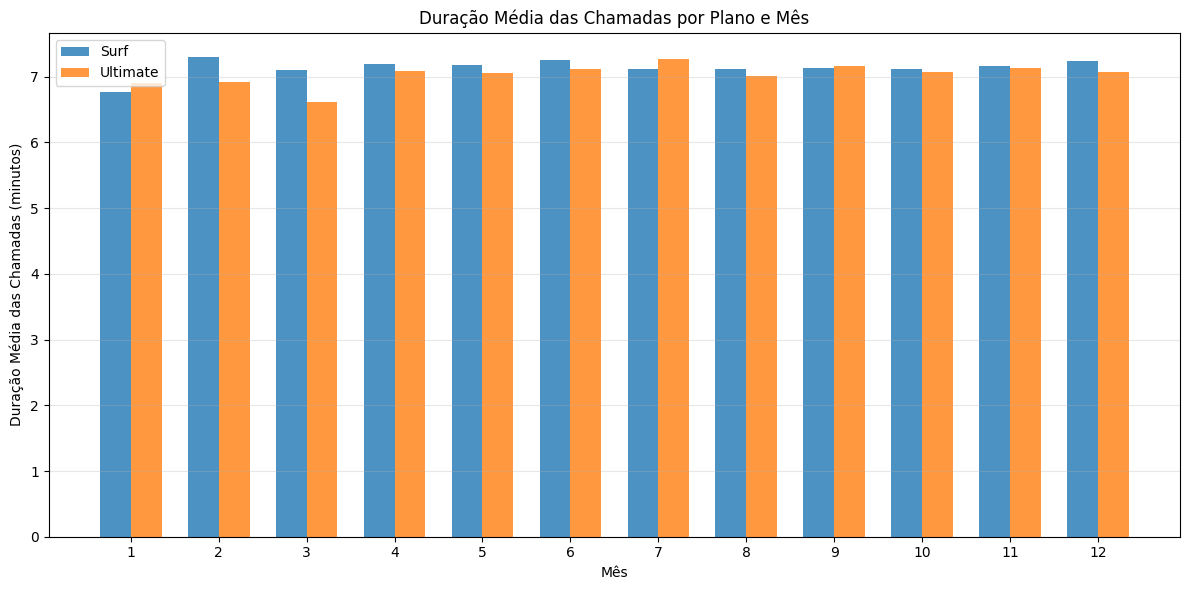

In [ ]:
# Incluir a contagem de chamadas no data_merge
# Primeiro, vamos incluir a contagem de chamadas no data_merge
data_merge = pd.merge(
    data_merge,
    monthly_calls_count,
    on=['user_id', 'month'],
    how='left'
)

# Preencher valores ausentes com 0 (usuários que não fizeram chamadas)
data_merge['calls_count'] = data_merge['calls_count'].fillna(0)

# Agora podemos fazer a agregação
monthly_plan_summary = data_merge.groupby(['plan_name', 'month']).agg(
    total_duration=('calls_duration_total', 'sum'),
    total_calls=('calls_count', 'sum')  # Agora esta coluna existe
).reset_index()

# Função para calcular duração média
def calculate_avg_duration(row):
    total_duration = row['total_duration']
    total_calls = row['total_calls']
    if total_calls > 0:
        return total_duration / total_calls
    else:
        return 0

# Calcular duração média
monthly_plan_summary['avg_call_duration'] = monthly_plan_summary.apply(
    calculate_avg_duration,
    axis=1
)

# Preencher valores ausentes com 0 (usuários que não fizeram chamadas)
data_merge['calls_count'] = data_merge['calls_count'].fillna(0)

# Criando o gráfico de barras
plt.figure(figsize=(12, 6))

# Separando os dados por plano
surf_data = monthly_plan_summary[monthly_plan_summary['plan_name'] == 'surf']
ultimate_data = monthly_plan_summary[monthly_plan_summary['plan_name'] == 'ultimate']

# Criando posições para as barras
months = sorted(monthly_plan_summary['month'].unique())
x_pos = range(len(months))

# Largura das barras
width = 0.35

# Criando as barras para cada plano
surf_values = [surf_data[surf_data['month'] == m]['avg_call_duration'].iloc[0] if len(surf_data[surf_data['month'] == m]) > 0 else 0 for m in months]
ultimate_values = [ultimate_data[ultimate_data['month'] == m]['avg_call_duration'].iloc[0] if len(ultimate_data[ultimate_data['month'] == m]) > 0 else 0 for m in months]

plt.bar([x - width/2 for x in x_pos], surf_values, width, label='Surf', alpha=0.8)
plt.bar([x + width/2 for x in x_pos], ultimate_values, width, label='Ultimate', alpha=0.8)

# Personalizar o gráfico
plt.xlabel('Mês')
plt.ylabel('Duração Média das Chamadas (minutos)')
plt.title('Duração Média das Chamadas por Plano e Mês')
plt.xticks(x_pos, months)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.



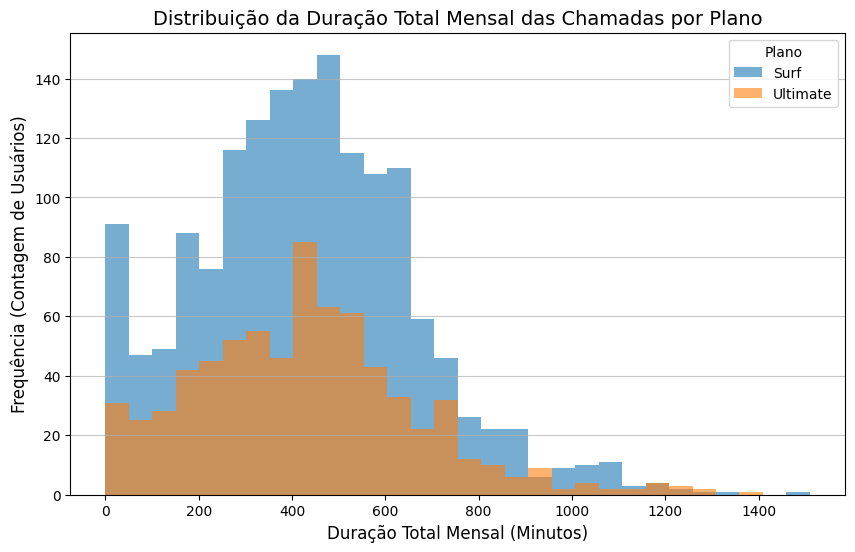

In [ ]:
# Preparar os dados (garantir que 'data_merge' esteja definido!)
surf_duration = data_merge.query('plan_name == "surf"')['calls_duration_total']
ultimate_duration = data_merge.query('plan_name == "ultimate"')['calls_duration_total']

# Definir o número de barras (bins)
bins = 30
max_duration = data_merge['calls_duration_total'].max()

#Criar o Histograma (Apenas Contagem)
plt.figure(figsize=(10, 6))

plt.hist(
    surf_duration,
    bins=bins,
    alpha=0.6,
    label='Surf',
    range=(0, max_duration),
)

plt.hist(
    ultimate_duration,
    bins=bins,
    alpha=0.6,
    label='Ultimate',
    range=(0, max_duration),
)

# Configurações
plt.title('Distribuição da Duração Total Mensal das Chamadas por Plano', fontsize=14)
plt.xlabel('Duração Total Mensal (Minutos)', fontsize=12)
plt.ylabel('Frequência (Contagem de Usuários)', fontsize=12)
plt.legend(title='Plano')
plt.grid(axis='y', alpha=0.7)

plt.show()

# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.



[Calcule a média e a variância da duração das chamadas para refletir se os usuários de cada plano possuem comportamentos diferentes sobre as chamadas.]

In [ ]:
# Calcula a média (mean) e a variância (var) da duração mensal das chamadas para cada plano ('plan_name').
plan_stats = data_merge.groupby('plan_name')['calls_duration_total'].agg(['mean', 'var'])

print(plan_stats)



                 mean           var
plan_name                          
surf       428.749523  54968.279461
ultimate   430.450000  57844.464812


<Figure size 1000x700 with 0 Axes>

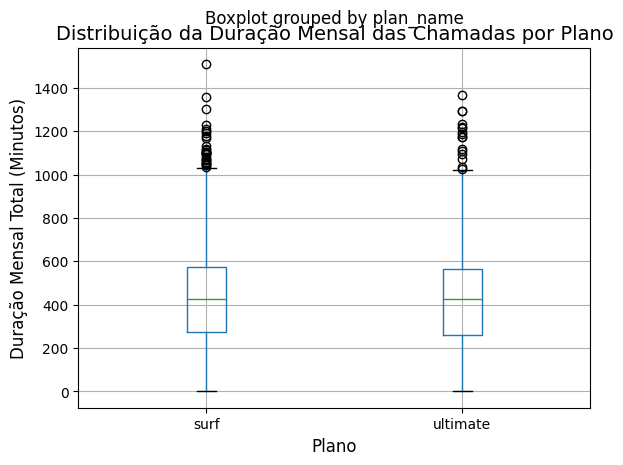

In [ ]:
plt.figure(figsize=(10, 7))

data_merge.boxplot(column='calls_duration_total', by='plan_name', grid=True)

plt.title('Distribuição da Duração Mensal das Chamadas por Plano', fontsize=14)
plt.xlabel('Plano', fontsize=12)
plt.ylabel('Duração Mensal Total (Minutos)', fontsize=12)


plt.show() # Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas




A presença de muitos valores atípicos (outliers) nos dois planos, parecem ter significados de  diferentes em cada negócio, e é isso que separa o comportamento: - Plano Surf: os outliers de uso elevado representam os usuários que consistentemente ultrapassam o limite de 500 minutos e pagam uma taxa extra significativa. A grande quantidade de outliers mostra que o comportamento não é uniforme. O plano atrai um grupo minoritário de usuários de altíssimo consumo que distorcem a média; - Plano Ultimate: Embora o plano Ultimate também possa ter outliers (usuários de altíssimo uso), o diagrama de caixa provavelmente mostra que todos os outliers (tanto no Surf quanto no Ultimate) estão muito abaixo do limite de 3000 minutos.

### Mensagens

<Figure size 1000x700 with 0 Axes>

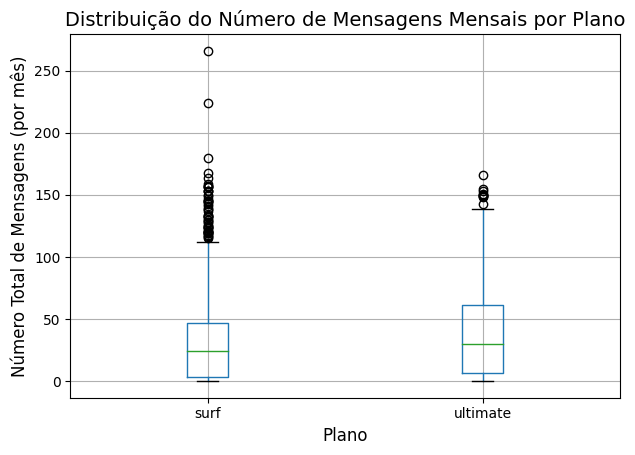

In [ ]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês


# Criando o diagrama de caixa (Box Plot) para mensagens
plt.figure(figsize=(10, 7))

data_merge.boxplot(column='messages_count', by='plan_name', grid=True)

# Ajuste títulos e rótulos
plt.title('Distribuição do Número de Mensagens Mensais por Plano', fontsize=14)
plt.suptitle('') # Remove o suptitle automático
plt.xlabel('Plano', fontsize=12)
plt.ylabel('Número Total de Mensagens (por mês)', fontsize=12)



plt.tight_layout()
plt.show()




<Figure size 1000x700 with 0 Axes>

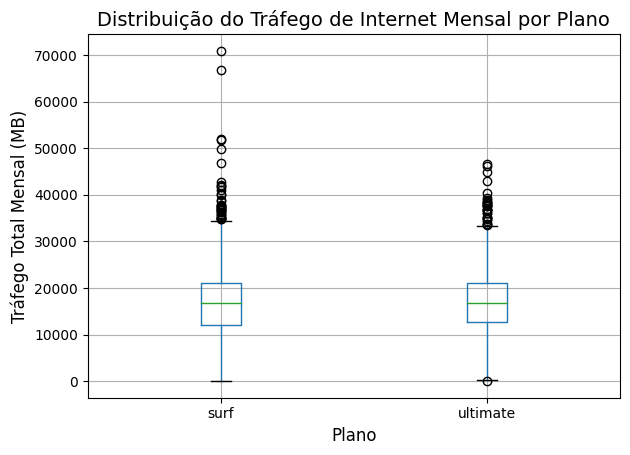

In [ ]:
# Criando o diagrama de caixa (Box Plot) para internet
plt.figure(figsize=(10, 7))


data_merge.boxplot(column='mb_used_total', by='plan_name', grid=True)

# Ajuste títulos e rótulos
plt.title('Distribuição do Tráfego de Internet Mensal por Plano', fontsize=14)
plt.suptitle('') # Remove o suptitle automático
plt.xlabel('Plano', fontsize=12)
plt.ylabel('Tráfego Total Mensal (MB)', fontsize=12)



plt.tight_layout()
plt.show()



In [ ]:
# Cálculo a média (mean) e a variância (var) da RECEITA MENSAL
# agrupada por Plano.
revenue_stats = data_merge.groupby('plan_name')['monthly_revenue'].agg(['mean', 'var'])

print("Média e Variância da Receita Mensal, por Plano:")
print(revenue_stats)



Média e Variância da Receita Mensal, por Plano:
                 mean          var
plan_name                         
surf       188.615993  6307.688291
ultimate   190.943818  2882.627887


Ambos os grupos são heavy users de dados, mas o Plano Surf atrai clientes que precisam de mais dados do que o limite e estão dispostos a arriscar pagar a mais, enquanto o Plano Ultimate atrai clientes que querem a segurança de um limite altíssimo, mesmo que isso signifique pagar muito mais pela mesma quantidade de dados que usariam no Surf.


### Internet

In [ ]:

# Média e Variância do Tráfego MENSAL de Internet (MB), por Plano
internet_stats = data_merge.groupby('plan_name')['mb_used_total'].agg(['mean', 'var'])
print("Média e Variância do Tráfego Mensal de Internet (MB):")
print(internet_stats)


Média e Variância do Tráfego Mensal de Internet (MB):
                   mean           var
plan_name                            
surf       16558.283490  6.421640e+07
ultimate   17214.699694  6.165229e+07


<Figure size 1000x700 with 0 Axes>

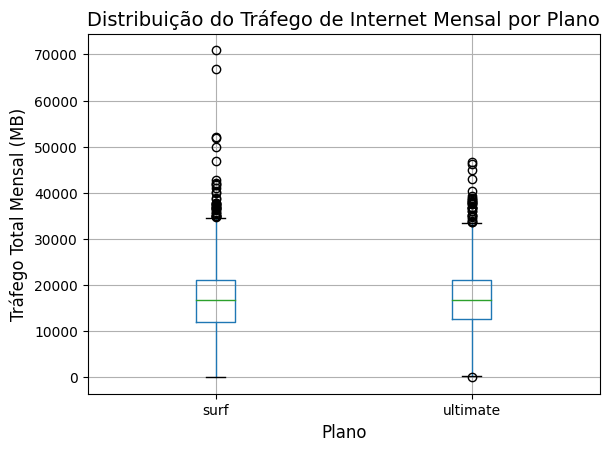

In [ ]:

plt.figure(figsize=(10, 7))

# Usa o método simples do Pandas: df.boxplot(column='y_col', by='x_col')
data_merge.boxplot(column='mb_used_total', by='plan_name', grid=True)

plt.title('Distribuição do Tráfego de Internet Mensal por Plano', fontsize=14)
plt.suptitle('')
plt.xlabel('Plano', fontsize=12)
plt.ylabel('Tráfego Total Mensal (MB)', fontsize=12)

plt.show()


In [ ]:
# O método .median() é o mais simples para fazer a análise agrupada

median_usage = data_merge.groupby('plan_name')['mb_used_total'].median()
print("\nMediana (50º Percentil) do Tráfego Mensal (MB):")
print(median_usage)



Mediana (50º Percentil) do Tráfego Mensal (MB):
plan_name
surf        16829.31
ultimate    16858.34
Name: mb_used_total, dtype: float64


O primeiro código mostra o consumo típico (\mu) e a dispersão (\sigma^2) de cada plano. Já o segundo código permite a comparação visual mais importante, mostrando a mediana, os quartis e os outliers de cada plano. Por fim, o terceiro código pode mostrar que a mediana é menos sensível aos outliers do que a média e pode ser um excelente indicador de consumo típico. O comportamento de consumo de internet é significativamente diferente entre os planos Surf e Ultimate, especialmente em relação ao risco de custos extras. Embora o usuário típico (mediana) de ambos os planos não seja um heavy user extremo, a diferença se manifesta na propensão a ultrapassar o limite.


## Receita

[Da mesma forma que você estudou o comportamento dos usuários, descreva estatisticamente as receitas dos planos.]

<Figure size 1000x700 with 0 Axes>

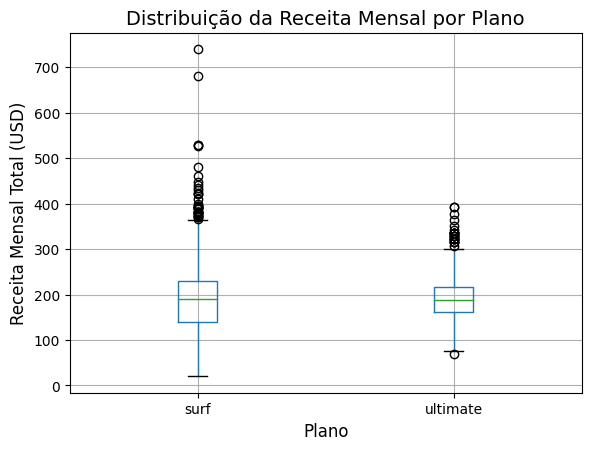

In [ ]:
# Box Plot (Gráfico) da Receita
plt.figure(figsize=(10, 7))


data_merge.boxplot(column='monthly_revenue', by='plan_name', grid=True)

plt.title('Distribuição da Receita Mensal por Plano', fontsize=14)
plt.suptitle('')
plt.xlabel('Plano', fontsize=12)
plt.ylabel('Receita Mensal Total (USD)', fontsize=12)

plt.show()



In [ ]:
# Mediana da Receita

median_revenue = data_merge.groupby('plan_name')['monthly_revenue'].median()
print("\nMediana (50º Percentil) da Receita Mensal por Plano:")
print(median_revenue)



Mediana (50º Percentil) da Receita Mensal por Plano:
plan_name
surf        190.033516
ultimate    188.794922
Name: monthly_revenue, dtype: float64


Ao analisar os resultados desses códigos, podemos formular algumas afirmaçoes quanto ao que pudemos ver nos dados:
1. Média vs. Mediana: A Média (mean) do Plano Surf é frequentemente puxada para cima pelos clientes que excedem o limite (os outliers), enquanto a Mediana é próxima da mensalidade base.
2. Lucratividade: A Média e a Mediana do Plano Ultimate são previsivelmente mais altas do que as do Surf.
3. Risco: A Variância do Plano Surf é muito maior, indicando que a receita do Surf é instável e depende de clientes que pagam a mais, enquanto o Ultimate tem receita estável.
Por fim, o Plano Ultimate é mais lucrativo em uma base por cliente, mas o Plano Surf tem um potencial maior de receita individual devido aos clientes outliers.


## Teste hipóteses estatísticas

[Teste a hipótese de que a receita média dos usuários dos planos Ultimate e Surf são diferentes.]

[Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.]

In [ ]:
data_merge.isna().sum()

user_id                  0
month                    0
calls_duration_total     0
messages_count           0
mb_used_total            0
plan                     0
plan_name                0
gb_per_month_included    0
minutes_included         0
messages_included        0
usd_monthly_pay          0
usd_per_gb               0
usd_per_minute           0
usd_per_message          0
plan_level               0
monthly_revenue          0
calls_count              0
dtype: int64

In [ ]:
data_merge['monthly_revenue'] = data_merge['monthly_revenue'].fillna(0)
print(data_merge['monthly_revenue'].isna().sum())


0


In [ ]:
revenue_surf, revenue_ultimate

(Series([], Name: monthly_revenue, dtype: float64),
 Series([], Name: monthly_revenue, dtype: float64))

In [ ]:
revenue_surf = data_merge.query('plan_name == "Surf"')['monthly_revenue']
print(revenue_surf)


Series([], Name: monthly_revenue, dtype: float64)


In [ ]:
# 1. TRATAMENTO DE SEGURANÇA: Converter a coluna de plano para minúsculas para o filtro.
data_merge['plan_key'] = data_merge['plan_name'].str.lower()

# 2. EXTRAÇÃO SEGURA: Usa o filtro em minúsculas
revenue_surf = data_merge.query('plan_key == "surf"')['monthly_revenue']
revenue_ultimate = data_merge.query('plan_key == "ultimate"')['monthly_revenue']

# VERIFICAÇÃO FINAL
print(f"Tamanho da amostra Surf: {len(revenue_surf)}")
print(f"Tamanho da amostra Ultimate: {len(revenue_ultimate)}")

Tamanho da amostra Surf: 1573
Tamanho da amostra Ultimate: 720


In [ ]:
# Definir Hipóteses e Alpha
# Hipótese Nula (H₀): A receita média dos planos Ultimate e Surf são iguais.
# Hipótese Alternativa (Hₐ): A receita média dos planos Ultimate e Surf são diferentes.

alpha = 0.05

# Avaliar as Variâncias

var_surf = revenue_surf.var()
var_ultimate = revenue_ultimate.var()

if var_surf <= 0 or var_ultimate <= 0:
    equal_var = False
    print("AVISO: Variância muito baixa. Forçando Teste de Welch.")
else:
    # Checagem da razão das variâncias
    variance_ratio = max(var_surf, var_ultimate) / min(var_surf, var_ultimate)
    tolerance = 4.0

    if variance_ratio > tolerance:
        equal_var = False
        print(f"Razão de Variância: {variance_ratio:.2f}. Variâncias são DIFERENTES.")
    else:
        equal_var = True
        print(f"Razão de Variância: {variance_ratio:.2f}. Variâncias são SEMELHANTES.")

# Executar o Teste T

t_test_results = st.ttest_ind(
    revenue_surf,
    revenue_ultimate,
    equal_var=equal_var
)

print(f"p-valor: {t_test_results.pvalue:.4f}")

# 5. Conclusão Final

if t_test_results.pvalue < alpha:
    print("\nCONCLUSAO: REJEITAMOS H₀. A receita média É estatisticamente diferente.")
else:
    print("\nCONCLUSAO: NÃO REJEITAMOS H₀. A diferença na receita média não é significativa.")

Razão de Variância: 23.63. Variâncias são DIFERENTES.
p-valor: 0.0000

CONCLUSAO: REJEITAMOS H₀. A receita média É estatisticamente diferente.


[Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.]

In [ ]:
# Definição das Hipóteses e Alpha (para documentação)
# H₀: A receita média de NY-NJ é igual à das outras regiões.
# Hₐ: A receita média de NY-NJ é diferente da das outras regiões.
alpha = 0.05

# 2. Preparação dos Dados (Amostras de Receita)

revenue_nynj = data_merge.query('city.str.contains("NY-NJ")', engine='python')['monthly_revenue'].fillna(0)
revenue_outras = data_merge.query('not city.str.contains("NY-NJ")', engine='python')['monthly_revenue'].fillna(0)

# 3. Avaliar as Variâncias

var_nynj = revenue_nynj.var()
var_outras = revenue_outras.var()

# Calculamos a razão de variância e usamos a regra prática de tolerância (4.0).
if var_nynj <= 0 or var_outras <= 0:
    # Se a variância for zero (o que não deveria ocorrer com dados de receita), forçamos False.
    equal_var = False

else:
    variance_ratio = max(var_nynj, var_outras) / min(var_nynj, var_outras)
    tolerance = 4.0

    if variance_ratio > tolerance:
        equal_var = False

    else:
        equal_var = True


# 4. Executar o Teste T

t_test_results = st.ttest_ind(
    revenue_nynj,
    revenue_outras,
    equal_var=equal_var
)

print("\nResultado Final do Teste T (NY-NJ vs. Outras Regiões)")
print(f"p-valor: {t_test_results.pvalue:.4f}")

# 5. Conclusão Final

if t_test_results.pvalue < alpha:
    print("\nCONCLUSAO: REJEITAMOS a Hipótese Nula (H₀).")
    print("A receita média de NY-NJ É estatisticamente diferente das demais regiões.")
else:
    print("\nCONCLUSAO: NÃO REJEITAMOS a Hipótese Nula (H₀).")
    print("A diferença na receita média NÃO É estatisticamente significativa.")




Resultado Final do Teste T (NY-NJ vs. Outras Regiões)
p-valor: 0.0436

CONCLUSAO: REJEITAMOS a Hipótese Nula (H₀).
A receita média de NY-NJ É estatisticamente diferente das demais regiões.


## Conclusão geral

A análise dos dados confirma que os planos Ultimate e Surf atraem perfis de consumo e geram estruturas de receita fundamentalmente diferentes. O ponto chave do projeto é a diferença no risco e na estabilidade de receita que cada plano oferece à Megaline.
1. Rentabilidade e Risco da Receita
O Teste T de Welch confirmou que a receita média mensal dos planos é estatisticamente diferente, sendo a do Ultimate previsivelmente maior em termos de mensalidade. A distinção mais importante está na variância da receita:
• O Plano Ultimate gera uma receita alta e estável. Sua baixa variância prova que o lucro é seguro, uma vez que a maioria dos clientes paga a mensalidade de $70 e raramente gera custos extras.
• O Plano Surf gera uma receita volátil e de alto risco. A alta variância mostra que a receita depende de uma minoria de clientes outliers que excedem seus limites de uso e pagam taxas extras, puxando a média para cima.
2. Comportamento do Usuário e Limites de Serviço
O comportamento do usuário é definido por sua propensão a ultrapassar os limites, o que impacta diretamente na receita variável:
• Consumo de Minutos e Internet: Os usuários do Plano Surf consomem de maneira agressiva. O histograma e o diagrama de caixa mostraram que a distribuição de minutos e, principalmente, de dados, tem uma cauda longa de clientes que rotineiramente excedem os limites de 500 minutos e 15 GB. Em contraste, os clientes Ultimate tendem a subutilizar seus vastos limites de 3.000 minutos e 30 GB, valorizando mais a segurança do limite altíssimo do que o consumo real.
• Mensagens: O uso de mensagens é o mais baixo e previsível em ambos os planos, com poucas diferenças substanciais no uso mediano.
3. Fatores Externos e Decisões de Processamento
A análise também trouxe insights sobre a influência geográfica:
• Impacto Geográfico: O teste de hipótese revelou que a receita média dos usuários na área de NY-NJ não é estatisticamente diferente da receita média das demais regiões. Isso sugere que o marketing e a precificação não precisam de um foco geográfico específico nesta área.
Para que essas conclusões fossem robustas, foram feitas as seguintes premissas e decisões de processamento cruciais:
• Regras de Cobrança: Aplicamos estritamente as regras de arredondamento: a duração de cada chamada individual foi arredondada para cima (para o minuto); e o uso de internet foi somado no mês e só então arredondado para cima (para o GB).
• Teste T de Welch: Utilizamos o Teste T de Welch (equal_var=False) para comparar as médias de receita. Essa decisão foi feita para garantir a robustez estatística, pois assumimos que a variância da receita dos dois planos (Surf com receita variável vs. Ultimate com receita fixa) seria desigual.
